In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd


In [ ]:

ds, info = tfds.load(
    "spoken_digit",
    split="train",
    as_supervised=True,
    with_info=True
)

DATASET_SIZE = info.splits["train"].num_examples
print(f"Total samples: {DATASET_SIZE}")
#print(info)


Total samples: 2500


## 2. Preview raw samples

In [ ]:
for audio, label in ds.take(3):
    print(f"Label: {label.numpy()}  |  Audio length: {audio.shape}")
    print("                          ")
    display(ipd.Audio(audio.numpy(), rate=8000))


Label: 2  |  Audio length: (1525,)
                          


Label: 1  |  Audio length: (2929,)
                          


Label: 9  |  Audio length: (6457,)
                          


In [ ]:
MAX_LEN = 16000   # ~2 seconds at 8 kHz

def preprocess(audio, label):
    audio = tf.cast(audio, tf.float32) / 32768.0 #bit depth , range from -1 to 1

    # Truncate if longer than MAX_LEN
    audio = audio[:MAX_LEN]

    # Zero-pad if shorter than MAX_LEN
    padding = tf.maximum(0, MAX_LEN - tf.shape(audio)[0])

    audio = tf.pad(audio, [[0, padding]])
    audio.set_shape([MAX_LEN])
    return audio, label

ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)


In [ ]:
for audio, label in ds.take(3):
    print(f"Label: {label.numpy()}  |  Audio length: {audio.shape}")
    print("                          ")
    display(ipd.Audio(audio.numpy(), rate=8000))


Label: 2  |  Audio length: (16000,)
                          


Label: 1  |  Audio length: (16000,)
                          


Label: 9  |  Audio length: (16000,)
                          


## 4. Train / Validation / Test split (70 / 15 / 15)

In [ ]:
ds = ds.shuffle(DATASET_SIZE, seed=42)

train_size = int(0.70 * DATASET_SIZE)
val_size   = int(0.15 * DATASET_SIZE)


train_ds = ds.take(train_size)
val_ds   = ds.skip(train_size).take(val_size)
test_ds  = ds.skip(train_size + val_size)

print(f"Train: {train_size}  |  Val: {val_size}  |  "
      f"Test: {DATASET_SIZE - train_size - val_size}")


Train: 1750  |  Val: 375  |  Test: 375


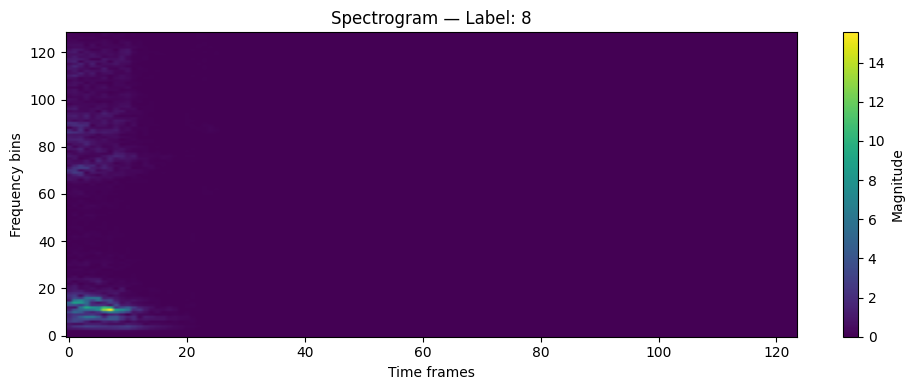

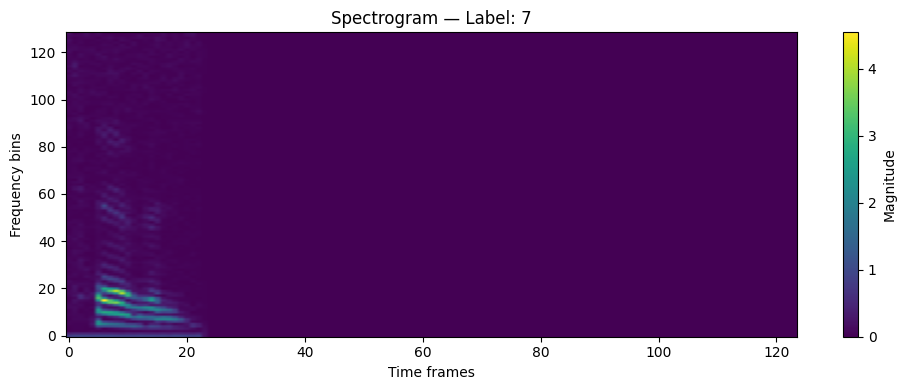

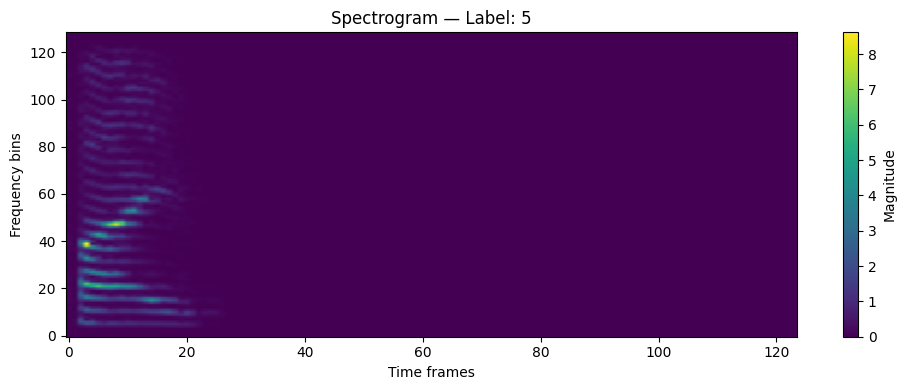

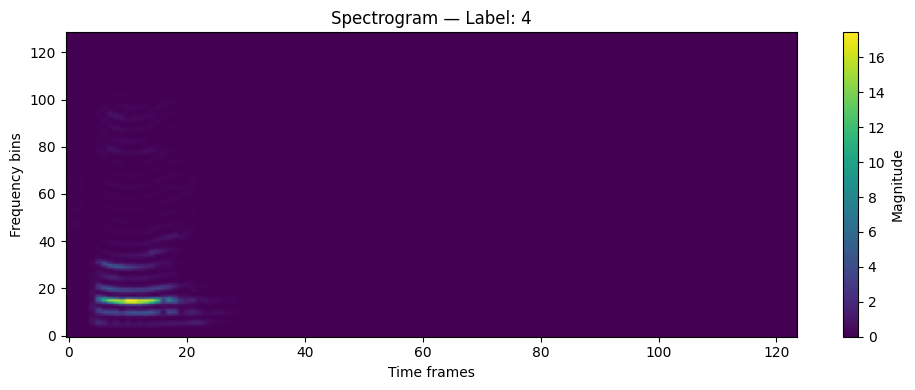

In [ ]:
for audio, label in train_ds.take(4):
    stft = tf.signal.stft(audio, frame_length=255, frame_step=128) # using sift to convert signal to freq
    spectrogram = tf.abs(stft) # short time fourier transform  it split the wave to frames

    plt.figure(figsize=(10, 4))
    plt.imshow(
        spectrogram.numpy().T,
        aspect="auto",
        origin="lower",
        cmap="viridis"
    )
    plt.title(f"Spectrogram — Label: {label.numpy()}")
    plt.xlabel("Time frames")
    plt.ylabel("Frequency bins")
    plt.colorbar(label="Magnitude")
    plt.tight_layout()
    plt.show()


In [ ]:
FRAME_LENGTH = 255
FRAME_STEP   = 128
N_MEL        = 80
N_MFCC       = 13
N_TIME       = 125
SAMPLE_RATE  = 8000

FFT_SIZE             = 256
NUM_SPECTROGRAM_BINS = FFT_SIZE // 2 + 1  # 129

def extract_mfcc(audio, label):
    stft  = tf.signal.stft(audio, frame_length=FRAME_LENGTH, frame_step=FRAME_STEP)
    power = tf.square(tf.abs(stft))

    mel_weights = tf.signal.linear_to_mel_weight_matrix( # matrix to convert freq to mel wight to be like human hearing
        num_mel_bins=N_MEL,
        num_spectrogram_bins=NUM_SPECTROGRAM_BINS,
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz=20.0,
        upper_edge_hertz=SAMPLE_RATE / 2
    )

    mel     = tf.matmul(power, mel_weights) # to get the power of each signal, concentrate on law freq and collect all high tofether
    log_mel = tf.math.log(mel + 1e-6) # Log focus on the shape of the signal regard its power
    mfcc    = tf.signal.dct(log_mel, type=2, n=N_MFCC) # get the most 13 info represented a signal

    mfcc = mfcc[:N_TIME, :]
    time_pad = tf.maximum(0, N_TIME - tf.shape(mfcc)[0])#make sure it has equal sizes
    mfcc = tf.pad(mfcc, [[0, time_pad], [0, 0]])
    mfcc.set_shape([N_TIME, N_MFCC])
    mfcc = tf.expand_dims(mfcc, -1) #add another diminsion to draw it
    return mfcc, label

train_2d = train_ds.map(extract_mfcc, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)
val_2d   = val_ds  .map(extract_mfcc, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)
test_2d  = test_ds .map(extract_mfcc, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

print("MFCC sample shape:", next(iter(train_2d))[0].shape)  # (32, 125, 13, 1)


MFCC sample shape: (32, 125, 13, 1)


## 7. 2D CNN on MFCC features

In [ ]:
model_2d = tf.keras.Sequential([
    #block1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same",input_shape=(N_TIME, N_MFCC, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    #block2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    #block3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation="softmax")
], name="2D_CNN_MFCC_Improved")

model_2d.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_2d.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "2D_CNN_MFCC_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 125, 13, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 125, 13, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 6, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 62, 6, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 3, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 3, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 1, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 340,746 (1.30 MB)

 Trainable params: 340,298 (1.30 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history_2d = model_2d.fit(
    train_2d,
    validation_data=val_2d,
    epochs=30,
    callbacks=callbacks
)

test_loss_2d, test_acc_2d = model_2d.evaluate(test_2d)
print(f"\n2D CNN — Test accuracy: {test_acc_2d*100:.4f}%  |  Test loss: {test_loss_2d:.4f}")


Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 203ms/step - accuracy: 0.1577 - loss: 2.4917 - val_accuracy: 0.1093 - val_loss: 2.2584 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 199ms/step - accuracy: 0.2063 - loss: 2.1305 - val_accuracy: 0.1813 - val_loss: 2.1260 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.2840 - loss: 1.9520 - val_accuracy: 0.2587 - val_loss: 1.9608 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step - accuracy: 0.3417 - loss: 1.7719 - val_accuracy: 0.4080 - val_loss: 1.7094 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step - accuracy: 0.3674 - loss: 1.6813 - val_accuracy: 0.4827 - val_loss: 1.4970 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.4154 - loss: 1.5643 - val_accuracy: 0.4800 - val_loss: 1.4085 - learning_rate: 0.0010
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.4417 - loss: 1.

## 8. 1D CNN on raw audio (no feature extraction)

In [ ]:
def add_channel(audio, label):
    return tf.expand_dims(audio, -1), label   # (16000, 1) 16000 sound in 1 channel

train_1d = train_ds.map(add_channel, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)
val_1d   = val_ds  .map(add_channel, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)
test_1d  = test_ds .map(add_channel, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

model_1d = tf.keras.Sequential([
    tf.keras.layers.Conv1D(128, kernel_size=80, strides=4, activation="relu", input_shape=(MAX_LEN, 1)),
    tf.keras.layers.MaxPooling1D(4),

    tf.keras.layers.Conv1D(128, kernel_size=3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling1D(4),

    tf.keras.layers.Conv1D(256, kernel_size=3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling1D(4),

    tf.keras.layers.Conv1D(512, kernel_size=3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling1D(4),

    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
], name="1D_CNN_M5")

model_1d.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
س
model_1d.summary()


Model: "1D_CNN_M5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3981, 128)      │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 995, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 995, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 248, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 248, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 62, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 62, 512)        │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 15, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,834 (2.62 MB)

 Trainable params: 685,834 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_1d = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history_1d = model_1d.fit(
    train_1d,
    validation_data=val_1d,
    epochs=30,
    callbacks=callbacks_1d
)

# Evaluate on held-out test set
test_loss_1d, test_acc_1d = model_1d.evaluate(test_1d)
print(f"\n1D CNN — Test accuracy: {test_acc_1d:.4f}  |  Test loss: {test_loss_1d:.4f}")


Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 52s 902ms/step - accuracy: 0.1126 - loss: 2.2716 - val_accuracy: 0.1600 - val_loss: 2.2112 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 49s 894ms/step - accuracy: 0.1451 - loss: 2.2118 - val_accuracy: 0.1333 - val_loss: 2.1042 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 84s 922ms/step - accuracy: 0.2120 - loss: 2.0743 - val_accuracy: 0.2320 - val_loss: 1.9837 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.3177 - loss: 1.8454 - val_accuracy: 0.3973 - val_loss: 1.6708 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 903ms/step - accuracy: 0.4011 - loss: 1.6767 - val_accuracy: 0.5227 - val_loss: 1.3975 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 889ms/step - accuracy: 0.4794 - loss: 1.4461 - val_accuracy: 0.5840 - val_loss: 1.1594 - learning_rate: 0.0010
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 83s 926ms/step - accuracy: 0.5514 - loss: 1.27

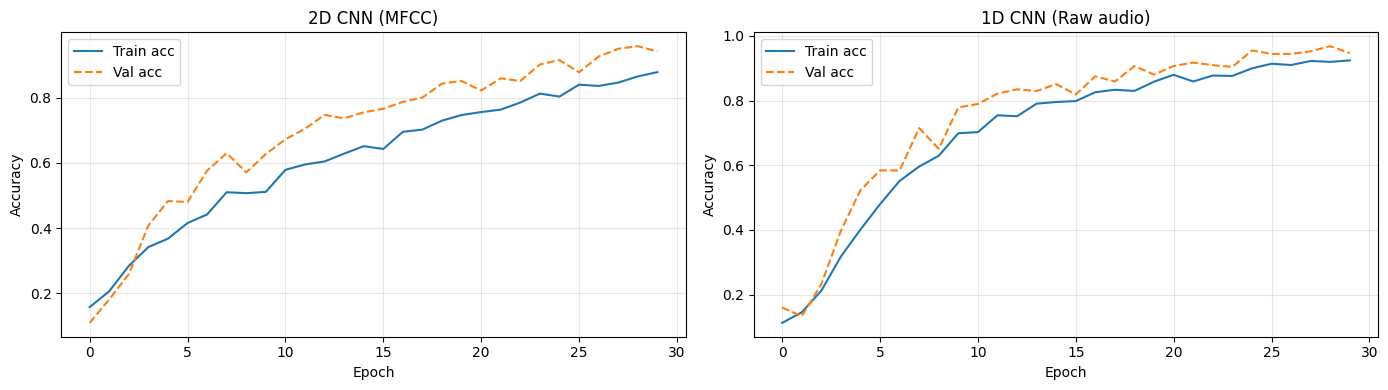


=== Final test results ===
  2D CNN (MFCC)       → accuracy: 0.9360
  1D CNN (raw audio)  → accuracy: 0.9387


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, history, name in zip(
        axes,
        [history_2d, history_1d],
        ["2D CNN (MFCC)", "1D CNN (Raw audio)"]):
    ax.plot(history.history["accuracy"],     label="Train acc")
    ax.plot(history.history["val_accuracy"], label="Val acc",  linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Final test results ===")
print(f"  2D CNN (MFCC)       → accuracy: {test_acc_2d:.4f}")
print(f"  1D CNN (raw audio)  → accuracy: {test_acc_1d:.4f}")
